# Self-Contained Topic Prevalence Scatter vs Tagesschau

This notebook is intentionally self-contained so it can be handed to someone else and adapted without importing local project modules.

Workflow:

1. load the saved merged article/topic CSVs
2. build one clean topic-prevalence comparison table
3. plot the six outlet-vs-Tagesschau scatter plots plus one combined grid

The plotting rule is simple:

- all non-outlier topics are plotted
- only topics that pass the caption rule receive text labels
- captioned points are darker; non-captioned points are lighter

## 1. Setup

This cell finds the `agenda_distortion` folder, chooses `v2` when available, and installs `adjustText` if it is missing.

In [1]:
import importlib.util
import re
import subprocess
import sys
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

if importlib.util.find_spec("adjustText") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "adjustText"])

from adjustText import adjust_text
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MultipleLocator

NOTEBOOK_DIR = Path.cwd().resolve()
if (NOTEBOOK_DIR / "outputs").exists():
    AGENDA_DIR = NOTEBOOK_DIR
elif (NOTEBOOK_DIR / "experiments" / "agenda_distortion").exists():
    AGENDA_DIR = NOTEBOOK_DIR / "experiments" / "agenda_distortion"
else:
    raise FileNotFoundError("Run this notebook from experiments/agenda_distortion or the repository root.")

OUTPUT_ROOT = AGENDA_DIR / "outputs"
ITERATION_ID = "v2" if (OUTPUT_ROOT / "v2" / "merged_articles.csv").exists() else "v1"
ITERATION_DIR = OUTPUT_ROOT / ITERATION_ID

ARTICLES_PATH = ITERATION_DIR / "merged_articles.csv"
TOPIC_INFO_PATH = ITERATION_DIR / "merged_topic_info.csv"

OUTLET_ORDER = [
    "rt",
    "antispiegel",
    "compact",
    "deutschlandkurier",
    "nius",
    "tichys",
]
OUTLET_LABEL_MAP = {
    "tagesschau": "Tagesschau",
    "rt": "RT",
    "antispiegel": "Antispiegel",
    "compact": "Compact",
    "deutschlandkurier": "Deutschlandkurier",
    "nius": "Nius",
    "tichys": "Tichys Einblick",
}

LABEL_RELATIVE_DEVIATION_THRESHOLD = 1.5
LABEL_SHARE_THRESHOLD_PCT = 2.5

DARK_POINT_COLOR = "#C46F3A"
LIGHT_POINT_COLOR = "#E7C8B8"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 150
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

print(f"Agenda dir: {AGENDA_DIR}")
print(f"Using iteration: {ITERATION_ID}")
print(f"Articles path: {ARTICLES_PATH}")
print(f"Topic info path: {TOPIC_INFO_PATH}")

Agenda dir: /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion
Using iteration: v2
Articles path: /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion/outputs/v2/merged_articles.csv
Topic info path: /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion/outputs/v2/merged_topic_info.csv


## 2. Load The Saved CSVs

The article file provides the article-level topic assignments. The topic info file provides the BERTopic keyword labels.

In [2]:
articles_df = pd.read_csv(ARTICLES_PATH, low_memory=False)
topic_info_df = pd.read_csv(TOPIC_INFO_PATH)

articles_df["merged_topic"] = pd.to_numeric(articles_df["merged_topic"], errors="coerce").astype("Int64")
topic_info_df["Topic"] = pd.to_numeric(topic_info_df["Topic"], errors="coerce").astype("Int64")

print(f"Articles loaded: {len(articles_df):,}")
print(f"Topic rows loaded: {len(topic_info_df):,}")
display(articles_df.head(3))
display(topic_info_df.head(10))

Articles loaded: 20,455
Topic rows loaded: 75


,document_id,source_name,outlet_key,outlet_label,Title,Date,URL,document,document_length,token_count,merged_topic,merged_display_topic,topic_keyword_label,manual_topic_name,topic_label,topic_display_label,merged_probability,umap_x,umap_y,source_file,original_index,tags,content,topline,ressort,regionId,type,source,Text,Category,Summary,Comments,Full_Text,Author,Categories,Authors,Inhalt,merged_display_label
0,https://www.tagesschau.de/api2u/afghanistan-flieger-pakistan-100.json?view=hasChanged&lastKnown=0E5CAD014B3854E66D94...,Tagesschau,tagesschau,Tagesschau,Deutschland holt zehn afghanische Familien aus Pakistan,2025-08-31 22:00:00,https://www.tagesschau.de/api2u/afghanistan-flieger-pakistan-100.json?view=hasChanged&lastKnown=0E5CAD014B3854E66D94...,"Zehn afghanische Familien dürfen aus Pakistan nach Deutschland ausreisen. Alle haben schon lange Aufnahmezusagen, sa...",3697,554,25,43.0,taliban_afghanistan_pakistan_afghanen,NaN,Topic 43 — taliban_afghanistan_pakistan_afghanen,Topic 43 — taliban_afghanistan_pakistan_afghanen,0.726265,1.736003,6.389868,tagesschau_2025-08-01_to_2025-10-31.csv,0,"[{'tag': 'Afghanistan'}, {'tag': 'Menschenrechte'}, {'tag': 'Taliban'}]",[{'value': '<strong>Zehn afghanische Familien dürfen aus Pakistan nach Deutschland ausreisen. Alle haben schon lange...,Flieger auf dem Weg nach Hannover,ausland,0.0,story,Tagesschau,"Zehn afghanische Familien dürfen aus Pakistan nach Deutschland ausreisen. Alle haben schon lange Aufnahmezusagen, sa...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Topic 43 — taliban_afghanistan_pakistan_afghanen
1,https://www.tagesschau.de/api2u/afghanistan-internet-104.json?view=hasChanged&lastKnown=F0C62FADA4B1BC09BDFE42049ACA...,Tagesschau,tagesschau,Tagesschau,Afghanistan ist wieder online,2025-09-30 22:00:00,https://www.tagesschau.de/api2u/afghanistan-internet-104.json?view=hasChanged&lastKnown=F0C62FADA4B1BC09BDFE42049ACA...,Handys und Internet funktionieren in Afghanistan wieder. Die islamistischen Taliban begründeten den Ausfall mit tech...,2336,296,25,43.0,taliban_afghanistan_pakistan_afghanen,NaN,Topic 43 — taliban_afghanistan_pakistan_afghanen,Topic 43 — taliban_afghanistan_pakistan_afghanen,0.634706,1.535961,6.577360,tagesschau_2025-08-01_to_2025-10-31.csv,1,"[{'tag': 'Afghanistan'}, {'tag': 'Internet'}]",[{'value': '<strong>Handys und Internet funktionieren in Afghanistan wieder. Die islamistischen Taliban begründeten ...,Nach Chaos im Land,ausland,0.0,story,Tagesschau,Handys und Internet funktionieren in Afghanistan wieder. Die islamistischen Taliban begründeten den Ausfall mit tech...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Topic 43 — taliban_afghanistan_pakistan_afghanen
2,https://www.tagesschau.de/api2u/aethiopien-deutsche-welle-korrespondenten-100.json?view=hasChanged&lastKnown=183183B...,Tagesschau,tagesschau,Tagesschau,Äthiopien suspendiert Deutsche-Welle-Journalisten,2025-10-23 22:00:00,https://www.tagesschau.de/api2u/aethiopien-deutsche-welle-korrespondenten-100.json?view=hasChanged&lastKnown=183183B...,"Die Deutsche Welle darf vorerst nicht mehr direkt aus Äthiopien berichten. Die Regierung hat angeordnet, dass neun K...",2795,363,32,52.0,proteste_wahl_kambodscha_wahlen,NaN,Topic 52 — proteste_wahl_kambodscha_wahlen,Topic 52 — proteste_wahl_kambodscha_wahlen,0.442792,7.500086,4.905983,tagesschau_2025-08-01_to_2025-10-31.csv,2,"[{'tag': 'Äthiopien'}, {'tag': 'Deutsche Welle'}]",[{'value': '<strong>Die Deutsche Welle darf vorerst nicht mehr direkt aus Äthiopien berichten. Die Regierung hat ang...,Medienbehörde EMA,ausland,0.0,story,Tagesschau,"Die Deutsche Welle darf vorerst nicht mehr direkt aus Äthiopien berichten. Die Regierung hat angeordnet, dass neun K...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Topic 52 — proteste_wahl_kambodscha_wahlen


,Topic,DisplayTopic,Count,Name,Representation,KeywordLabel,TopicLabel,DisplayLabel,ManualTopicName
0,-1,NaN,880,-1_papst_afd_kirche_leo,"['-1', 'papst', 'afd', 'kirche', 'leo']",-1_papst_afd_kirche_leo,Outliers,Outliers,NaN
1,0,3.0,892,israel_hamas_gazastreifen_gaza,"['israel', 'hamas', 'gazastreifen', 'gaza']",israel_hamas_gazastreifen_gaza,Topic 3 — israel_hamas_gazastreifen_gaza,Topic 3 — israel_hamas_gazastreifen_gaza,NaN
2,1,1.0,1156,ukraine_putin_selenskyj_trump,"['ukraine', 'putin', 'selenskyj', 'trump']",ukraine_putin_selenskyj_trump,Topic 1 — ukraine_putin_selenskyj_trump,Topic 1 — ukraine_putin_selenskyj_trump,NaN
3,2,9.0,479,venezuela_maduro_trump_venezuelas,"['venezuela', 'maduro', 'trump', 'venezuelas']",venezuela_maduro_trump_venezuelas,Topic 9 — venezuela_maduro_trump_venezuelas,Topic 9 — venezuela_maduro_trump_venezuelas,NaN
4,3,18.0,213,dollar_dax_anleger_punkten,"['dollar', 'dax', 'anleger', 'punkten']",dollar_dax_anleger_punkten,Topic 18 — dollar_dax_anleger_punkten,Topic 18 — dollar_dax_anleger_punkten,NaN
5,4,6.0,734,social media_media_jugendliche_social,"['social media', 'media', 'jugendliche', 'social']",social media_media_jugendliche_social,Topic 6 — social media_media_jugendliche_social,Topic 6 — social media_media_jugendliche_social,NaN
6,5,7.0,759,ukraine_russland_russischen_ukrainische,"['ukraine', 'russland', 'russischen', 'ukrainische']",ukraine_russland_russischen_ukrainische,Topic 7 — ukraine_russland_russischen_ukrainische,Topic 7 — ukraine_russland_russischen_ukrainische,NaN
7,6,16.0,347,patienten_medikamente_studie_erkrankungen,"['patienten', 'medikamente', 'studie', 'erkrankungen']",patienten_medikamente_studie_erkrankungen,Topic 16 — patienten_medikamente_studie_erkrankungen,Topic 16 — patienten_medikamente_studie_erkrankungen,NaN
8,7,19.0,206,preise_lebensmittel_verbraucher_weihnachten,"['preise', 'lebensmittel', 'verbraucher', 'weihnachten']",preise_lebensmittel_verbraucher_weihnachten,Topic 19 — preise_lebensmittel_verbraucher_weihnachten,Topic 19 — preise_lebensmittel_verbraucher_weihnachten,NaN
9,8,5.0,802,bundesanwaltschaft_gericht_haft_prozess,"['bundesanwaltschaft', 'gericht', 'haft', 'prozess']",bundesanwaltschaft_gericht_haft_prozess,Topic 5 — bundesanwaltschaft_gericht_haft_prozess,Topic 5 — bundesanwaltschaft_gericht_haft_prozess,NaN


## 3. Build One Clean Topic Prevalence Table

This is the core table used for every plot.

For each topic and each alternative outlet, it stores:

- `tagesschau_share_pct`
- `outlet_share_pct`
- `relative_deviation`
- `should_label`

In [3]:
def minimal_topic_label(raw_label: object, max_words: int = 3) -> str:
    if pd.isna(raw_label) or raw_label is None:
        return "Unlabeled topic"
    text = str(raw_label).strip()
    text = re.sub(r"^Topic\s+\d+\s+[—-]\s+", "", text)
    text = re.sub(r"^\s*-?\d+_", "", text)
    tokens = [token.strip(" ,.;:-") for token in re.split(r"[_\s/]+", text) if token.strip(" ,.;:-")]
    deduped = []
    seen = set()
    for token in tokens:
        token_key = token.lower()
        if token_key in seen:
            continue
        seen.add(token_key)
        deduped.append(token)
        if len(deduped) >= max_words:
            break
    if not deduped:
        fallback = text.replace("_", " ").strip()
        return fallback or "Unlabeled topic"
    return " / ".join(deduped)

non_outlier_articles_df = articles_df.loc[
    articles_df["merged_topic"].notna() & (articles_df["merged_topic"] != -1)
].copy()
non_outlier_articles_df["merged_topic"] = non_outlier_articles_df["merged_topic"].astype(int)

non_outlier_topic_info_df = topic_info_df.loc[
    topic_info_df["Topic"].notna() & (topic_info_df["Topic"] != -1)
].copy()
non_outlier_topic_info_df["merged_topic"] = non_outlier_topic_info_df["Topic"].astype(int)

topic_universe_df = (
    non_outlier_topic_info_df[["merged_topic"]]
    .drop_duplicates()
    .sort_values("merged_topic")
    .reset_index(drop=True)
)

raw_label_column = next(
    (
        column
        for column in ("Name", "KeywordLabel", "TopicLabel", "DisplayLabel")
        if column in non_outlier_topic_info_df.columns
    ),
    None,
)
if raw_label_column is None:
    raise KeyError("No usable topic label column found in merged_topic_info.csv.")

topic_label_df = (
    non_outlier_topic_info_df[["merged_topic", raw_label_column]]
    .rename(columns={raw_label_column: "raw_label"})
    .drop_duplicates("merged_topic")
    .sort_values("merged_topic")
    .reset_index(drop=True)
)
topic_label_df["plot_label"] = topic_label_df["raw_label"].map(minimal_topic_label)

outlet_totals_df = (
    non_outlier_articles_df.groupby(["outlet_key", "outlet_label"], dropna=False)
    .size()
    .rename("outlet_total_articles")
    .reset_index()
)

share_frames = []
for _, total_row in outlet_totals_df.iterrows():
    outlet_key = str(total_row["outlet_key"])
    outlet_label = str(total_row["outlet_label"])
    outlet_total = int(total_row["outlet_total_articles"])
    outlet_counts = (
        non_outlier_articles_df.loc[non_outlier_articles_df["outlet_key"] == outlet_key, "merged_topic"]
        .value_counts()
    )
    outlet_frame = topic_universe_df.copy()
    outlet_frame["outlet_key"] = outlet_key
    outlet_frame["outlet_label"] = outlet_label
    outlet_frame["article_count"] = outlet_frame["merged_topic"].map(outlet_counts).fillna(0).astype(int)
    outlet_frame["outlet_total_articles"] = outlet_total
    outlet_frame["share_pct"] = np.where(
        outlet_total > 0,
        (outlet_frame["article_count"] / outlet_total) * 100.0,
        0.0,
    )
    share_frames.append(outlet_frame)

topic_share_long_df = pd.concat(share_frames, ignore_index=True)

tagesschau_shares_df = (
    topic_share_long_df.loc[
        topic_share_long_df["outlet_key"] == "tagesschau",
        ["merged_topic", "share_pct"],
    ]
    .rename(columns={"share_pct": "tagesschau_share_pct"})
)

comparison_frames = []
for outlet_key in OUTLET_ORDER:
    outlet_shares_df = (
        topic_share_long_df.loc[
            topic_share_long_df["outlet_key"] == outlet_key,
            ["merged_topic", "share_pct"],
        ]
        .rename(columns={"share_pct": "outlet_share_pct"})
    )
    comparison_df = (
        topic_universe_df
        .merge(tagesschau_shares_df, on="merged_topic", how="left")
        .merge(outlet_shares_df, on="merged_topic", how="left")
        .merge(topic_label_df, on="merged_topic", how="left")
    )
    comparison_df["tagesschau_share_pct"] = comparison_df["tagesschau_share_pct"].fillna(0.0)
    comparison_df["outlet_share_pct"] = comparison_df["outlet_share_pct"].fillna(0.0)
    comparison_df["share_gap_pct"] = comparison_df["outlet_share_pct"] - comparison_df["tagesschau_share_pct"]
    comparison_df["relative_deviation"] = (
        comparison_df["share_gap_pct"]
        / np.maximum(comparison_df["tagesschau_share_pct"], 0.1)
    )
    comparison_df["combined_share_pct"] = (
        comparison_df["tagesschau_share_pct"] + comparison_df["outlet_share_pct"]
    )
    comparison_df["outlet_key"] = outlet_key
    comparison_df["outlet_label"] = OUTLET_LABEL_MAP[outlet_key]
    comparison_df["should_label"] = (
        comparison_df["relative_deviation"].abs() > LABEL_RELATIVE_DEVIATION_THRESHOLD
    ) & (
        (comparison_df["outlet_share_pct"] > LABEL_SHARE_THRESHOLD_PCT)
        | (comparison_df["tagesschau_share_pct"] > LABEL_SHARE_THRESHOLD_PCT)
    )
    comparison_frames.append(comparison_df)

prevalence_comparison_df = pd.concat(comparison_frames, ignore_index=True)

print(f"Non-outlier topics: {len(topic_universe_df)}")
print(f"Comparison rows: {len(prevalence_comparison_df):,}")
display(topic_label_df.head(15))
display(prevalence_comparison_df.head(15))

Non-outlier topics: 74
Comparison rows: 444


,merged_topic,raw_label,plot_label
0,0,israel_hamas_gazastreifen_gaza,israel / hamas / gazastreifen
1,1,ukraine_putin_selenskyj_trump,ukraine / putin / selenskyj
2,2,venezuela_maduro_trump_venezuelas,venezuela / maduro / trump
3,3,dollar_dax_anleger_punkten,dollar / dax / anleger
4,4,social media_media_jugendliche_social,social / media / jugendliche
5,5,ukraine_russland_russischen_ukrainische,ukraine / russland / russischen
6,6,patienten_medikamente_studie_erkrankungen,patienten / medikamente / studie
7,7,preise_lebensmittel_verbraucher_weihnachten,preise / lebensmittel / verbraucher
8,8,bundesanwaltschaft_gericht_haft_prozess,bundesanwaltschaft / gericht / haft
9,9,china_xi_indien_trump,china / xi / indien


,merged_topic,tagesschau_share_pct,outlet_share_pct,raw_label,plot_label,share_gap_pct,relative_deviation,combined_share_pct,outlet_key,outlet_label,should_label
0,0,6.533073,4.644314,israel_hamas_gazastreifen_gaza,israel / hamas / gazastreifen,-1.888759,-0.289107,11.177386,rt,RT,False
1,1,4.659498,12.075215,ukraine_putin_selenskyj_trump,ukraine / putin / selenskyj,7.415717,1.591527,16.734713,rt,RT,True
2,2,3.030303,4.395106,venezuela_maduro_trump_venezuelas,venezuela / maduro / trump,1.364803,0.450385,7.425410,rt,RT,False
3,3,2.948843,0.226552,dollar_dax_anleger_punkten,dollar / dax / anleger,-2.722291,-0.923173,3.175395,rt,RT,False
4,4,2.508961,2.061622,social media_media_jugendliche_social,social / media / jugendliche,-0.447338,-0.178296,4.570583,rt,RT,False
5,5,2.867384,9.447213,ukraine_russland_russischen_ukrainische,ukraine / russland / russischen,6.579830,2.294716,12.314597,rt,RT,True
6,6,2.916259,0.702311,patienten_medikamente_studie_erkrankungen,patienten / medikamente / studie,-2.213949,-0.759174,3.618570,rt,RT,False
7,7,1.792115,0.294517,preise_lebensmittel_verbraucher_weihnachten,preise / lebensmittel / verbraucher,-1.497597,-0.835659,2.086632,rt,RT,False
8,8,3.144347,4.145899,bundesanwaltschaft_gericht_haft_prozess,bundesanwaltschaft / gericht / haft,1.001553,0.318525,7.290246,rt,RT,False
9,9,1.710655,3.398278,china_xi_indien_trump,china / xi / indien,1.687623,0.986536,5.108933,rt,RT,False


## 4. Plotting Helpers

These functions use only the table built above.

In [4]:
axis_max_pct = float(
    np.ceil(
        prevalence_comparison_df[["tagesschau_share_pct", "outlet_share_pct"]]
        .to_numpy()
        .max()
        + 1.0
    )
)

if axis_max_pct <= 6:
    tick_step_pct = 1.0
elif axis_max_pct <= 12:
    tick_step_pct = 2.0
else:
    tick_step_pct = 5.0

def style_scatter_axis(ax):
    ax.set_facecolor("white")
    ax.grid(True, color="#D9D9D9", alpha=0.30, linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D0D0D0")
    ax.spines["bottom"].set_color("#D0D0D0")
    ax.set_axisbelow(True)
    ax.set_xlim(0, axis_max_pct)
    ax.set_ylim(0, axis_max_pct)
    ax.xaxis.set_major_locator(MultipleLocator(tick_step_pct))
    ax.yaxis.set_major_locator(MultipleLocator(tick_step_pct))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0f}%"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0f}%"))

def scatter_legend_handles():
    legend_title = (
        f"Caption rule: |relative deviation| > {LABEL_RELATIVE_DEVIATION_THRESHOLD:.1f}"
        f"\nand topic share > {LABEL_SHARE_THRESHOLD_PCT:.1f}%"
    )
    handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markersize=6,
            markerfacecolor=DARK_POINT_COLOR,
            markeredgecolor="none",
            alpha=0.85,
            label="Captioned topics",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markersize=6,
            markerfacecolor=LIGHT_POINT_COLOR,
            markeredgecolor="none",
            alpha=0.55,
            label="Not captioned",
        ),
    ]
    return handles, legend_title

def annotate_selected_topics(ax, labeled_df):
    ordered = labeled_df.sort_values(
        ["combined_share_pct", "relative_deviation"],
        ascending=[False, False],
    ).reset_index(drop=True)
    if ordered.empty:
        return

    texts = []
    for _, row in ordered.iterrows():
        texts.append(
            ax.text(
                float(row["tagesschau_share_pct"]),
                float(row["outlet_share_pct"]),
                row["plot_label"],
                fontsize=7,
                fontweight="normal",
                color="#2F2F2F",
                zorder=4,
            )
        )

    adjust_text(
        texts,
        x=ordered["tagesschau_share_pct"].astype(float).to_numpy(),
        y=ordered["outlet_share_pct"].astype(float).to_numpy(),
        ax=ax,
        force_text=0.5,
        force_static=0.3,
        expand=(1.5, 1.5),
        arrowprops=dict(arrowstyle="-", color="#999999", lw=0.5, alpha=0.6),
    )

def plot_single_outlet_scatter(ax, outlet_key: str, show_legend: bool = False):
    outlet_df = (
        prevalence_comparison_df.loc[prevalence_comparison_df["outlet_key"] == outlet_key]
        .copy()
        .sort_values(["combined_share_pct", "relative_deviation"], ascending=[False, False])
    )
    labeled_df = outlet_df.loc[outlet_df["should_label"]].copy()
    unlabeled_df = outlet_df.loc[~outlet_df["should_label"]].copy()

    style_scatter_axis(ax)
    ax.plot(
        [0, axis_max_pct],
        [0, axis_max_pct],
        linestyle=(0, (4, 4)),
        linewidth=1.0,
        color="#B5B5B5",
        zorder=1,
    )

    if not unlabeled_df.empty:
        ax.scatter(
            unlabeled_df["tagesschau_share_pct"],
            unlabeled_df["outlet_share_pct"],
            s=18,
            color=LIGHT_POINT_COLOR,
            alpha=0.55,
            linewidths=0.0,
            zorder=2,
        )

    if not labeled_df.empty:
        ax.scatter(
            labeled_df["tagesschau_share_pct"],
            labeled_df["outlet_share_pct"],
            s=18,
            color=DARK_POINT_COLOR,
            alpha=0.85,
            linewidths=0.0,
            zorder=3,
        )

    annotate_selected_topics(ax, labeled_df)

    if show_legend:
        legend_handles, legend_title = scatter_legend_handles()
        ax.legend(
            handles=legend_handles,
            title=legend_title,
            loc="lower right",
            fontsize=7,
            title_fontsize=7,
            frameon=False,
        )

    ax.set_title(OUTLET_LABEL_MAP[outlet_key], fontsize=12, pad=10)
    return outlet_df

## 5. Render The Scatter Plots In-Notebook

This cell renders the combined grid and the six outlet plots directly in the notebook.

No figure files are written to disk.

### Combined grid

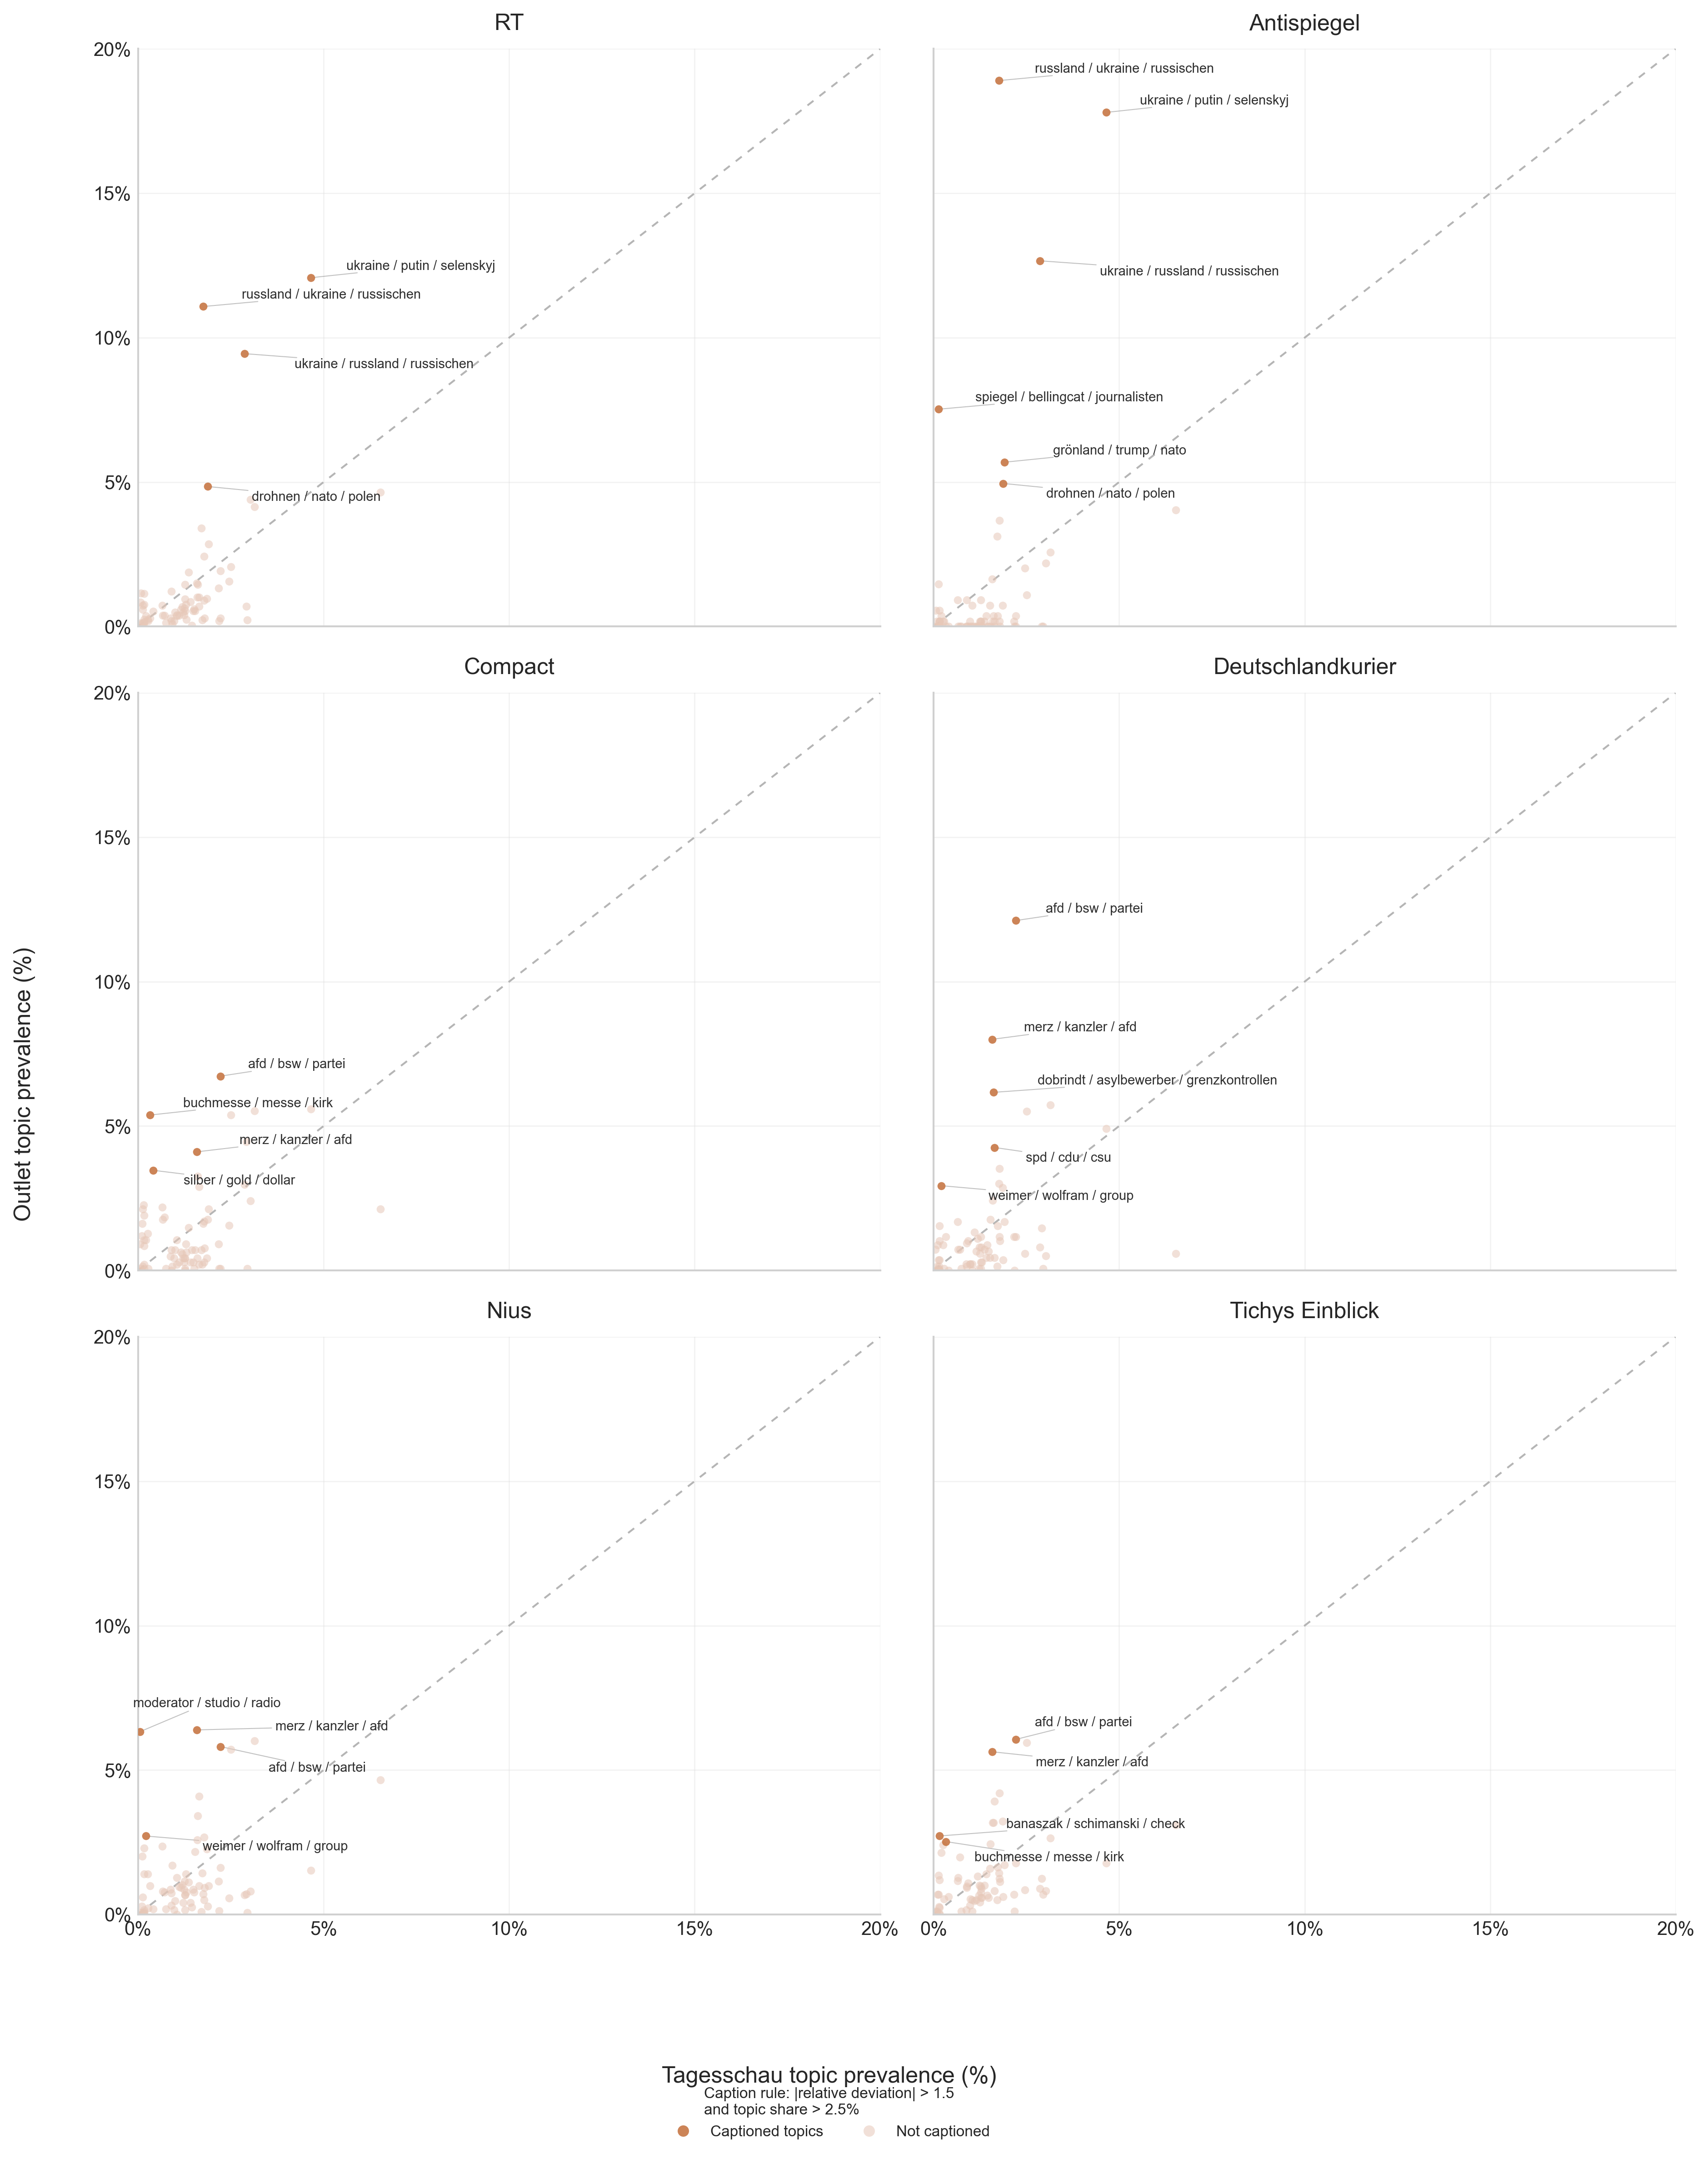

### RT

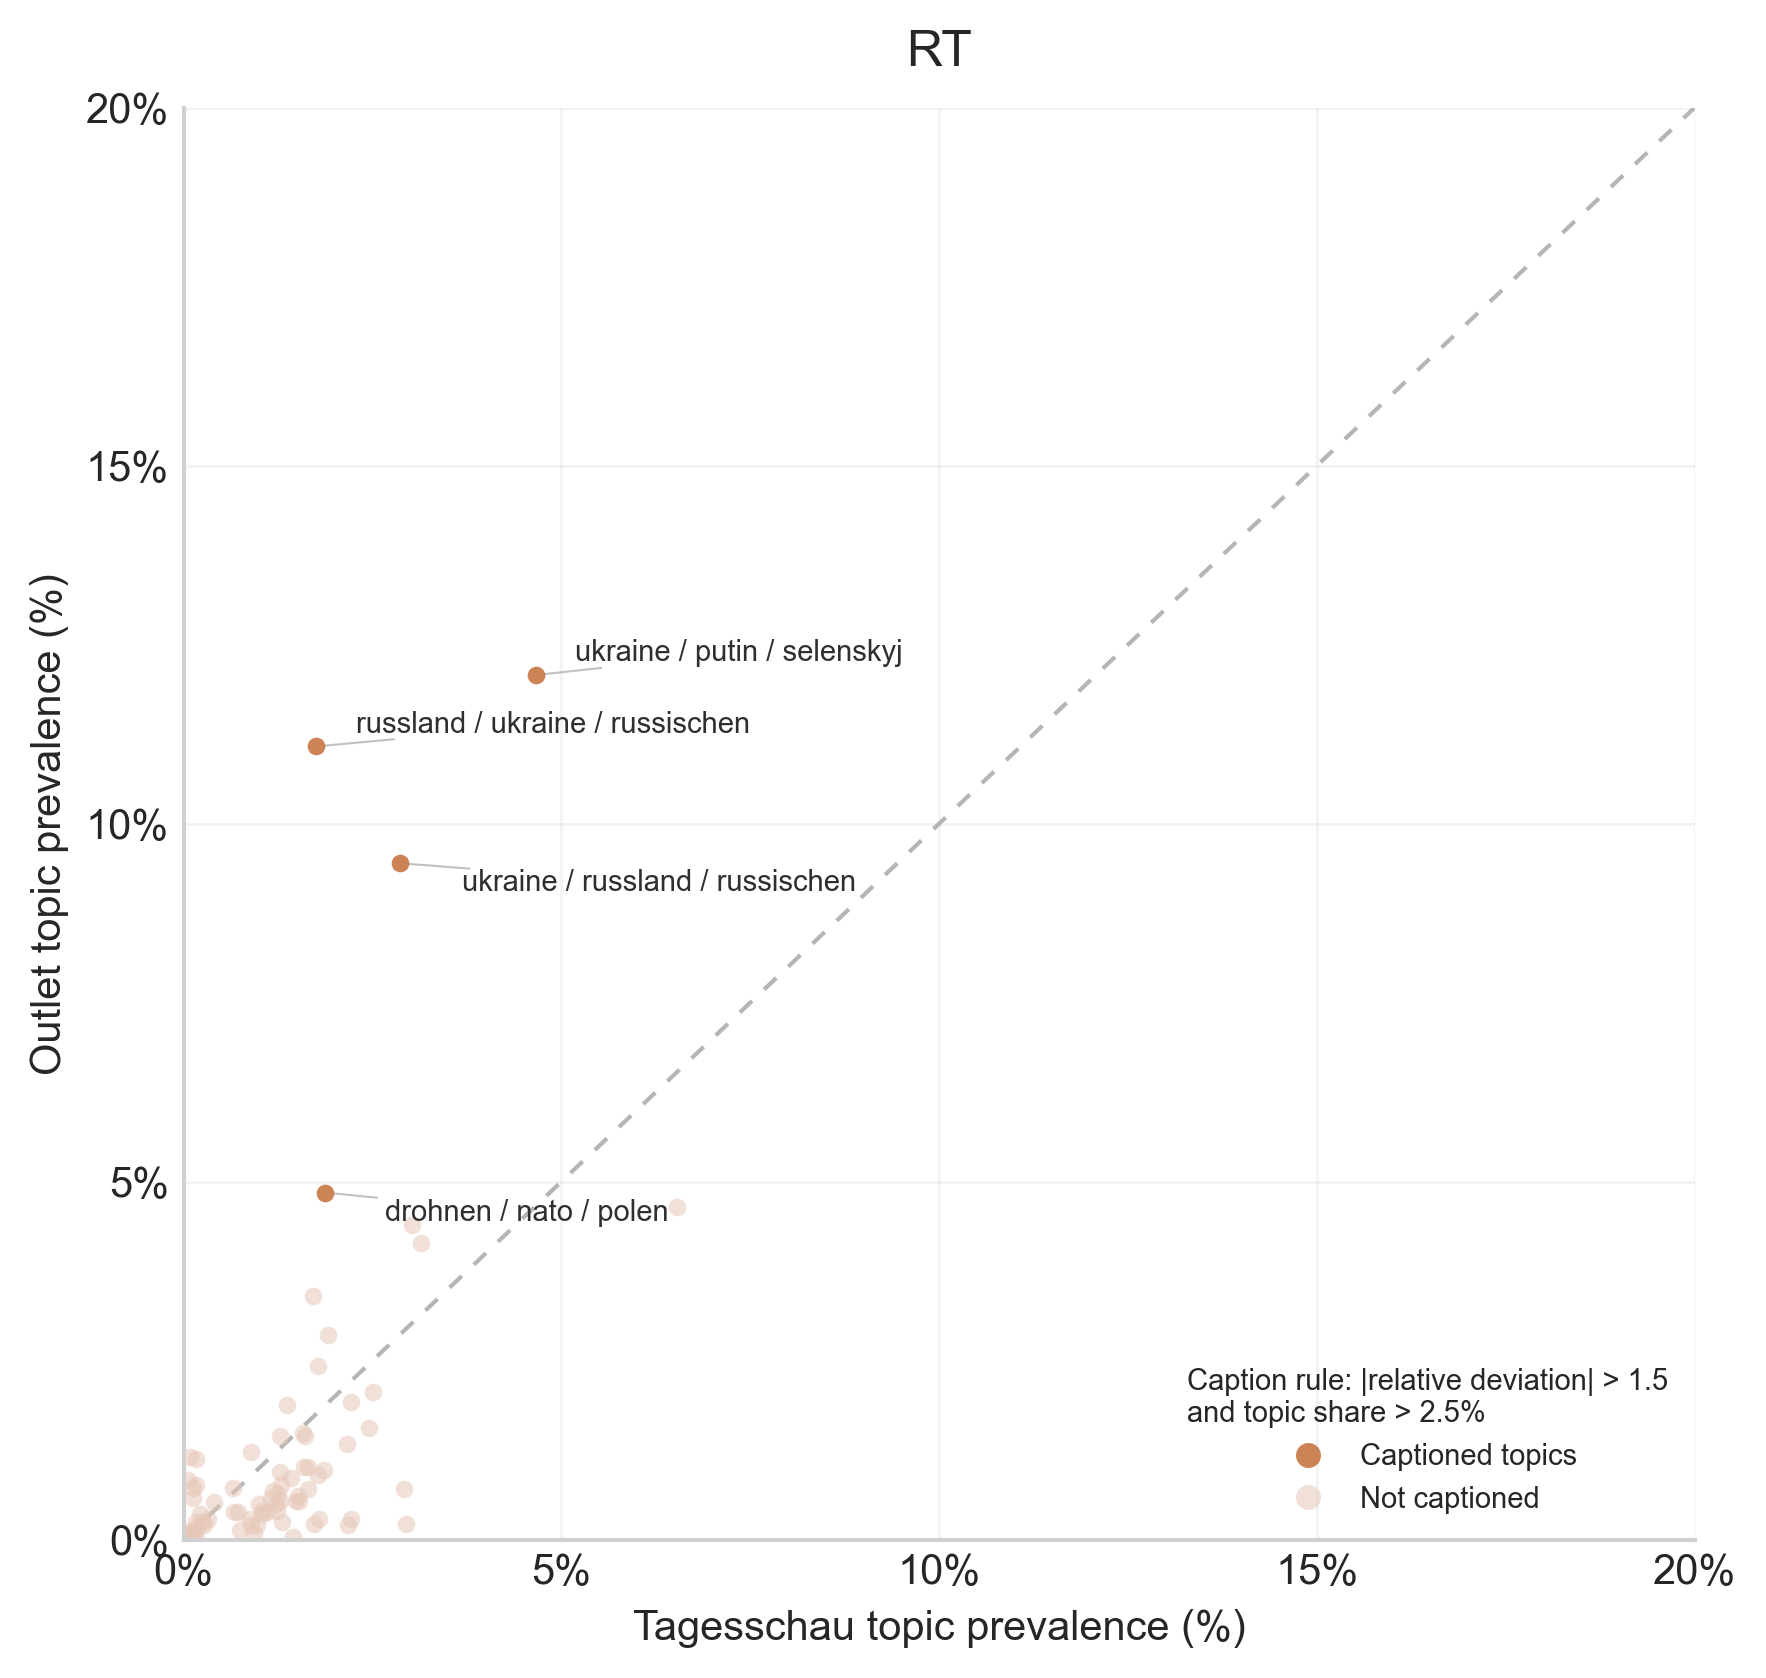

### Antispiegel

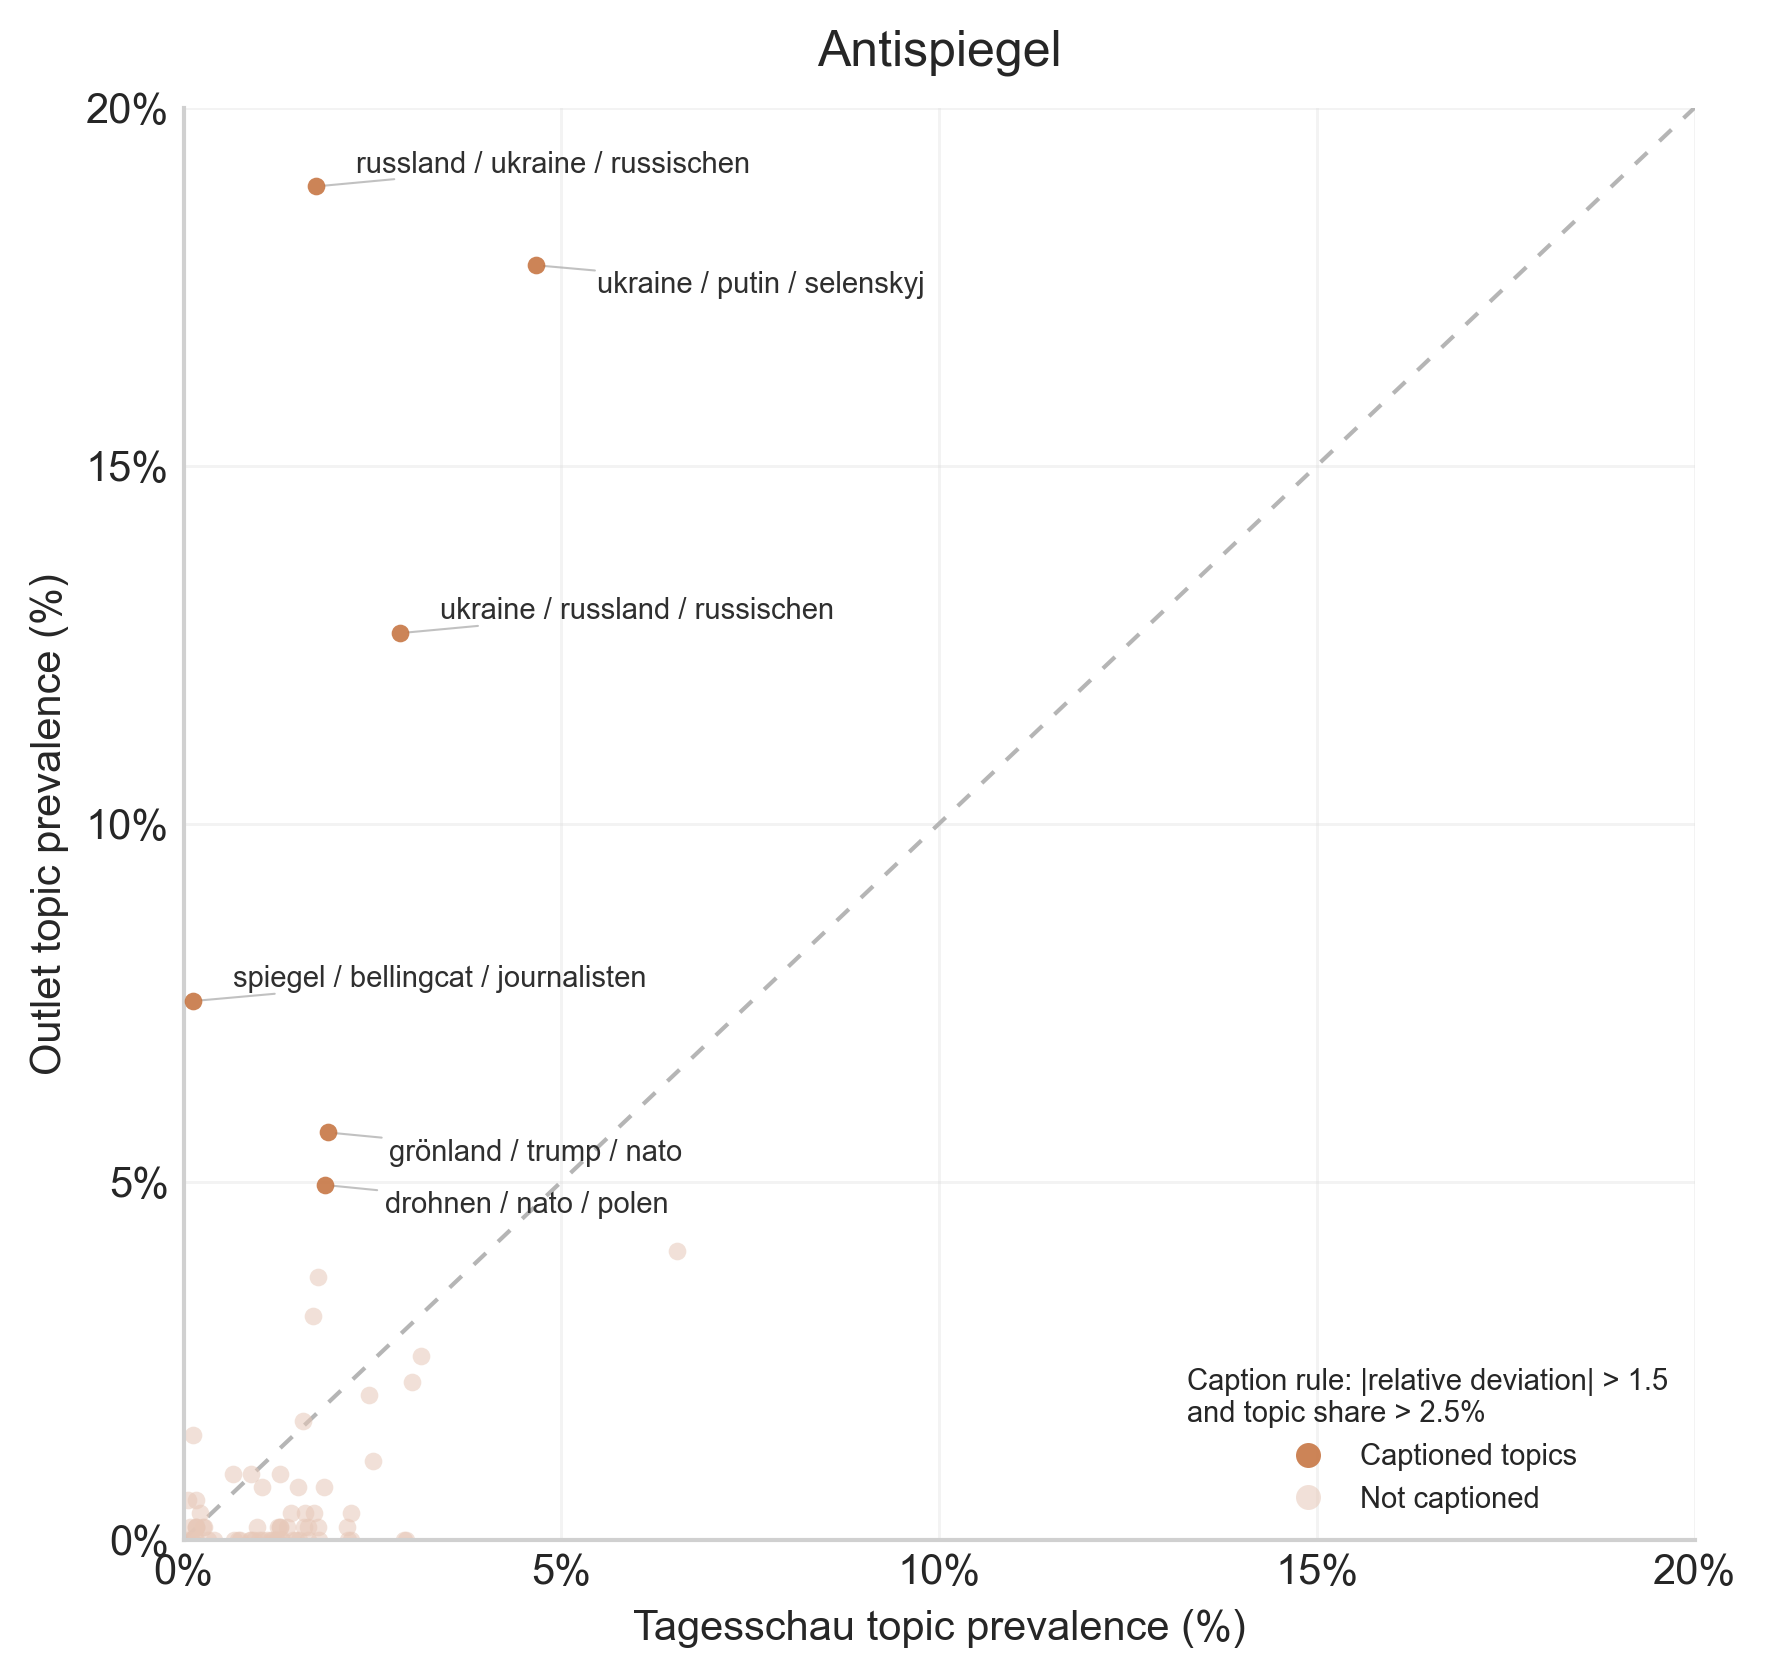

### Compact

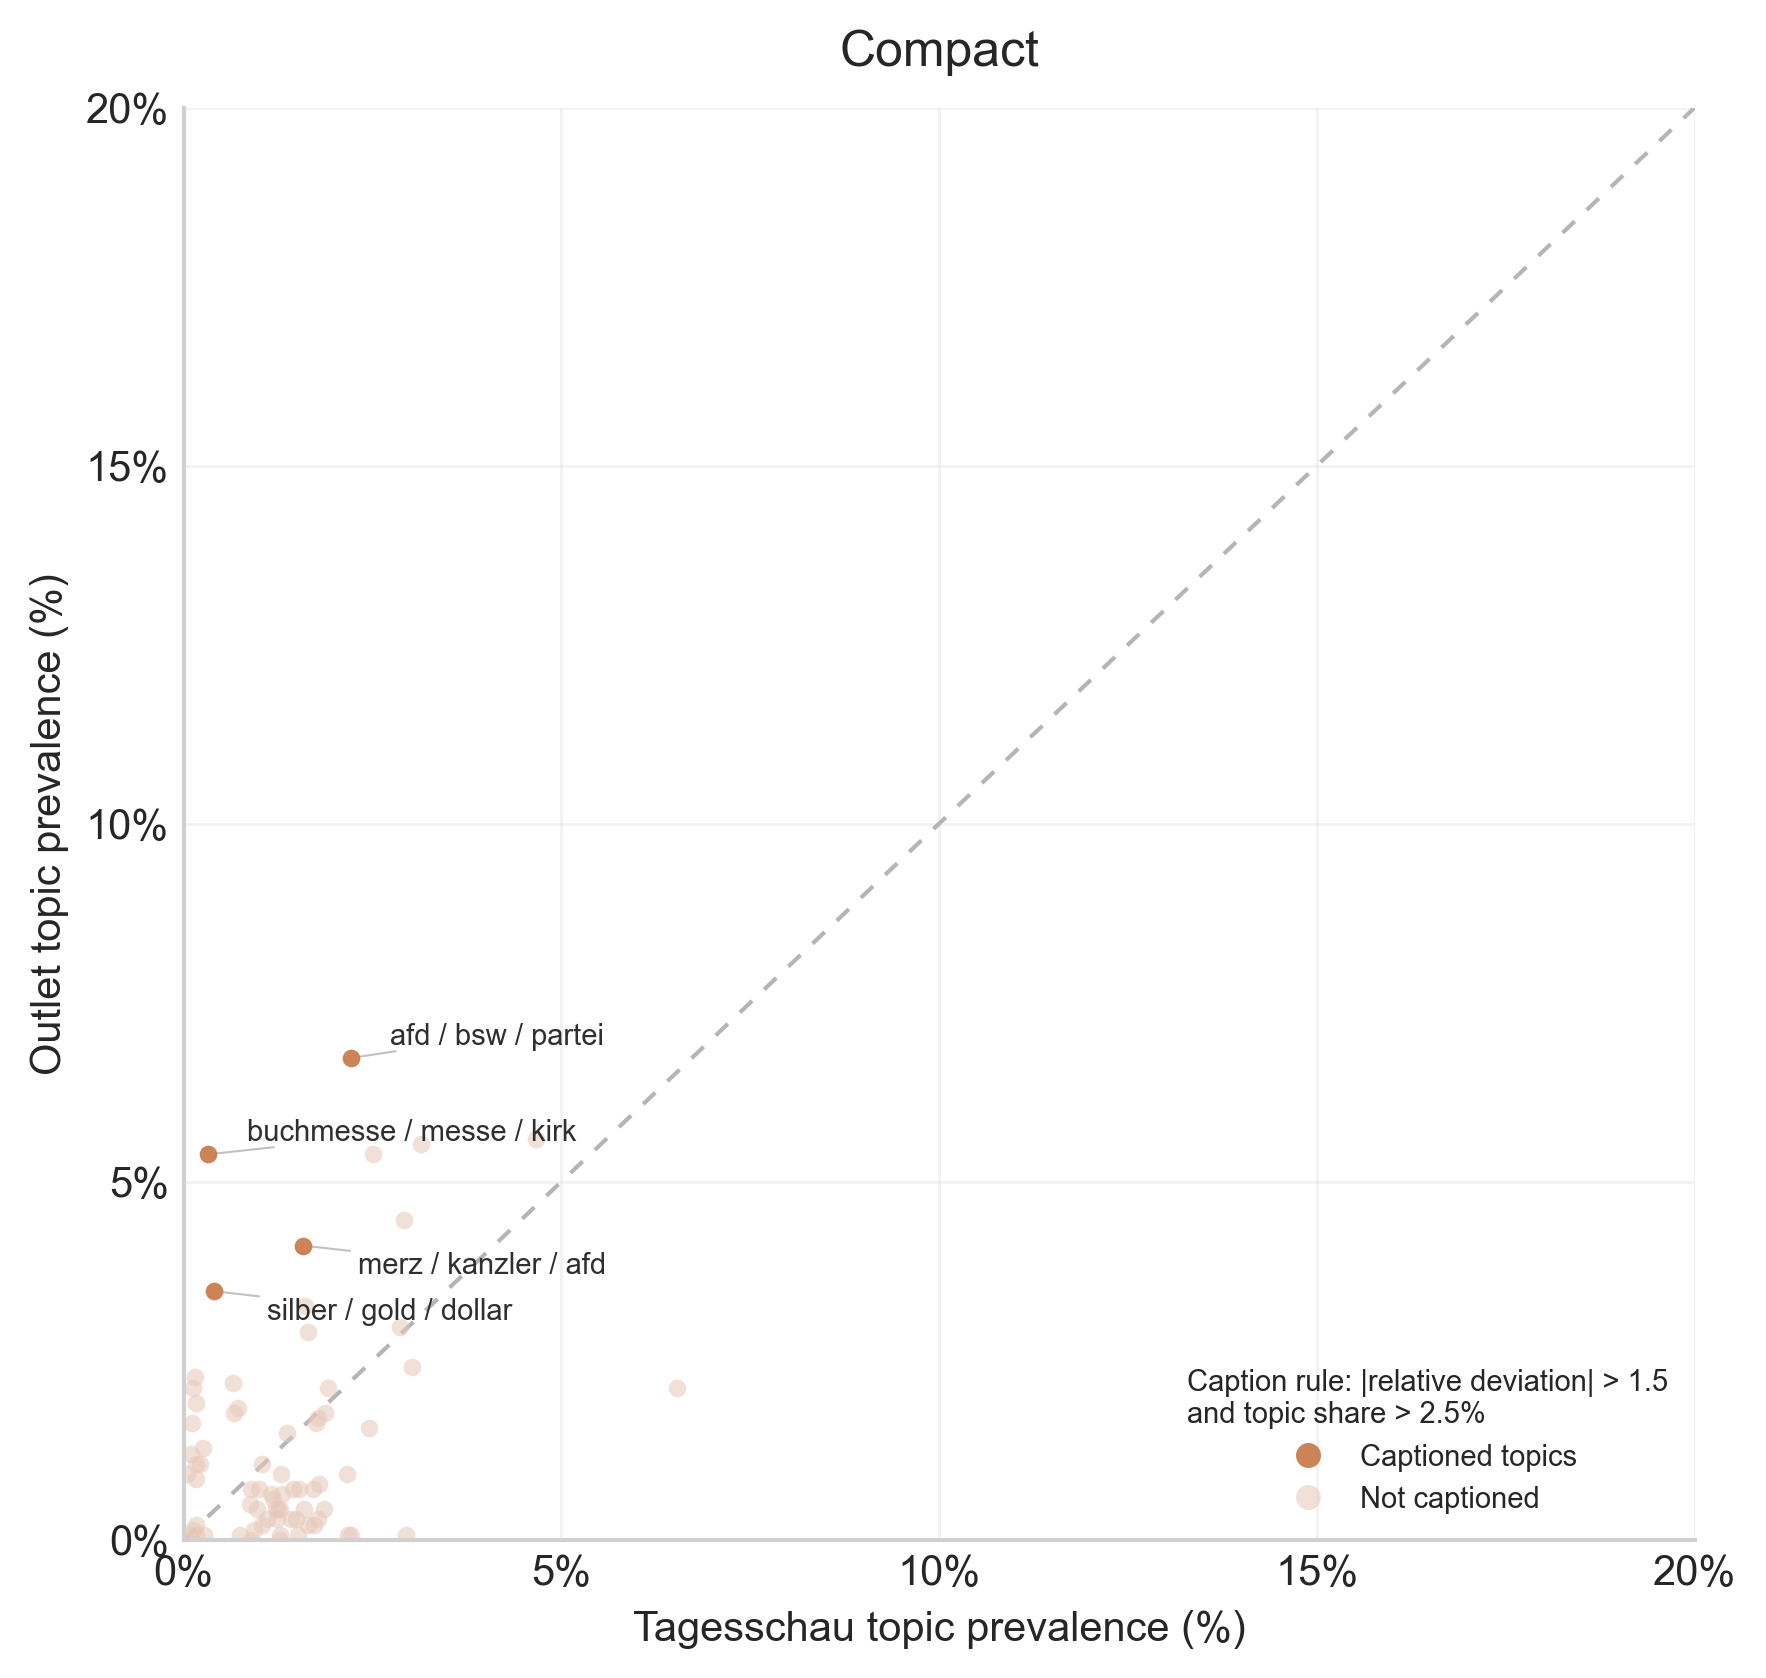

### Deutschlandkurier

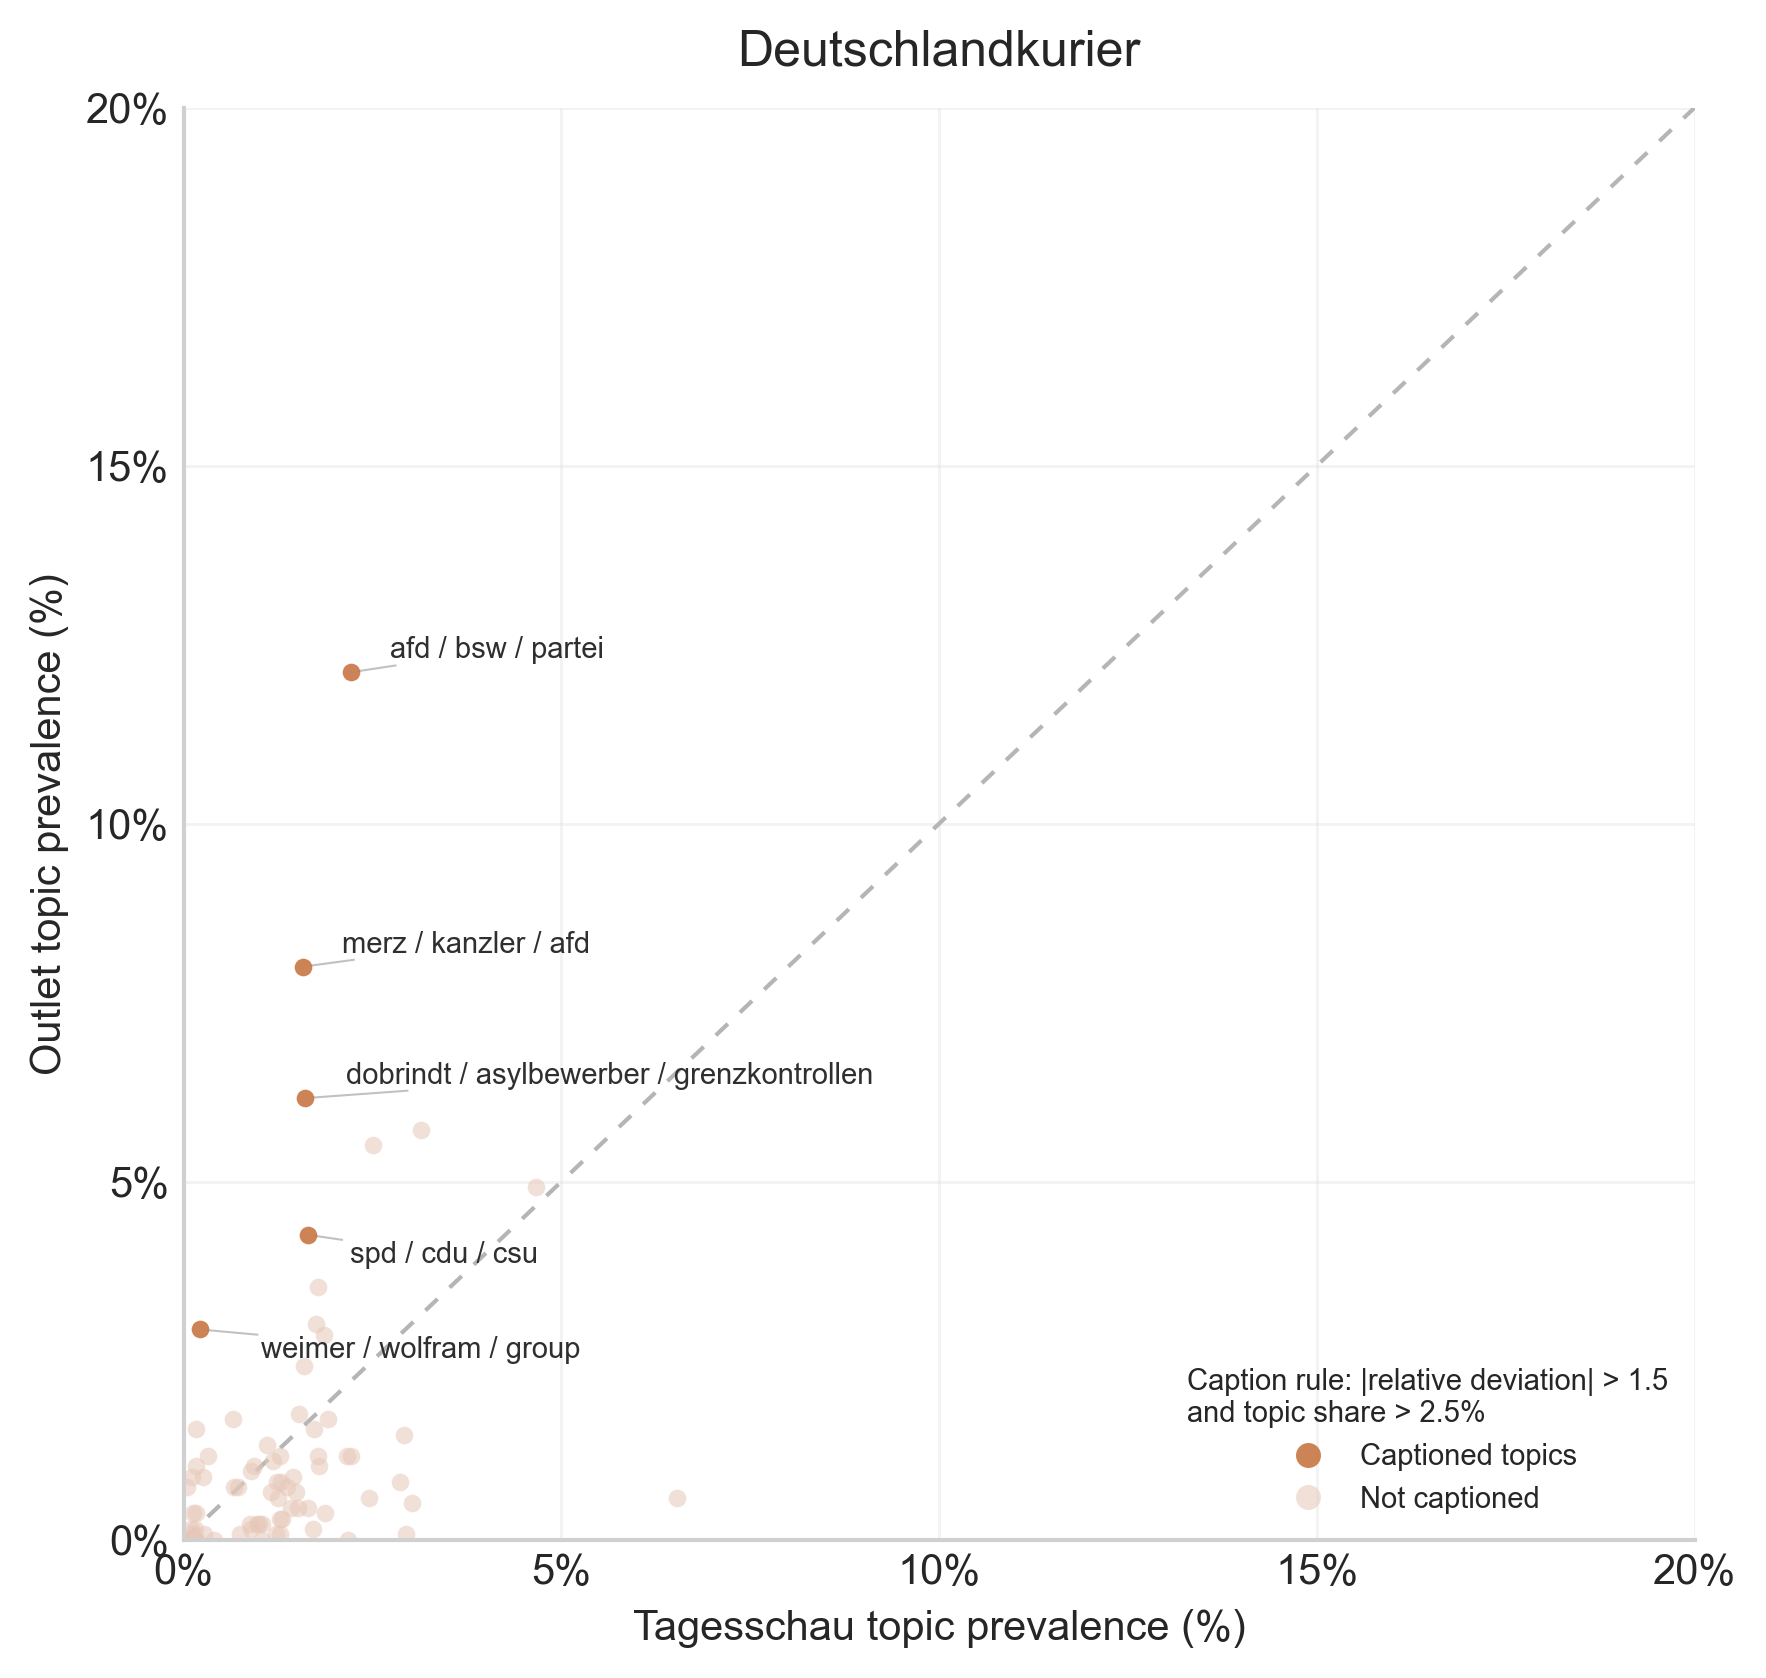

### Nius

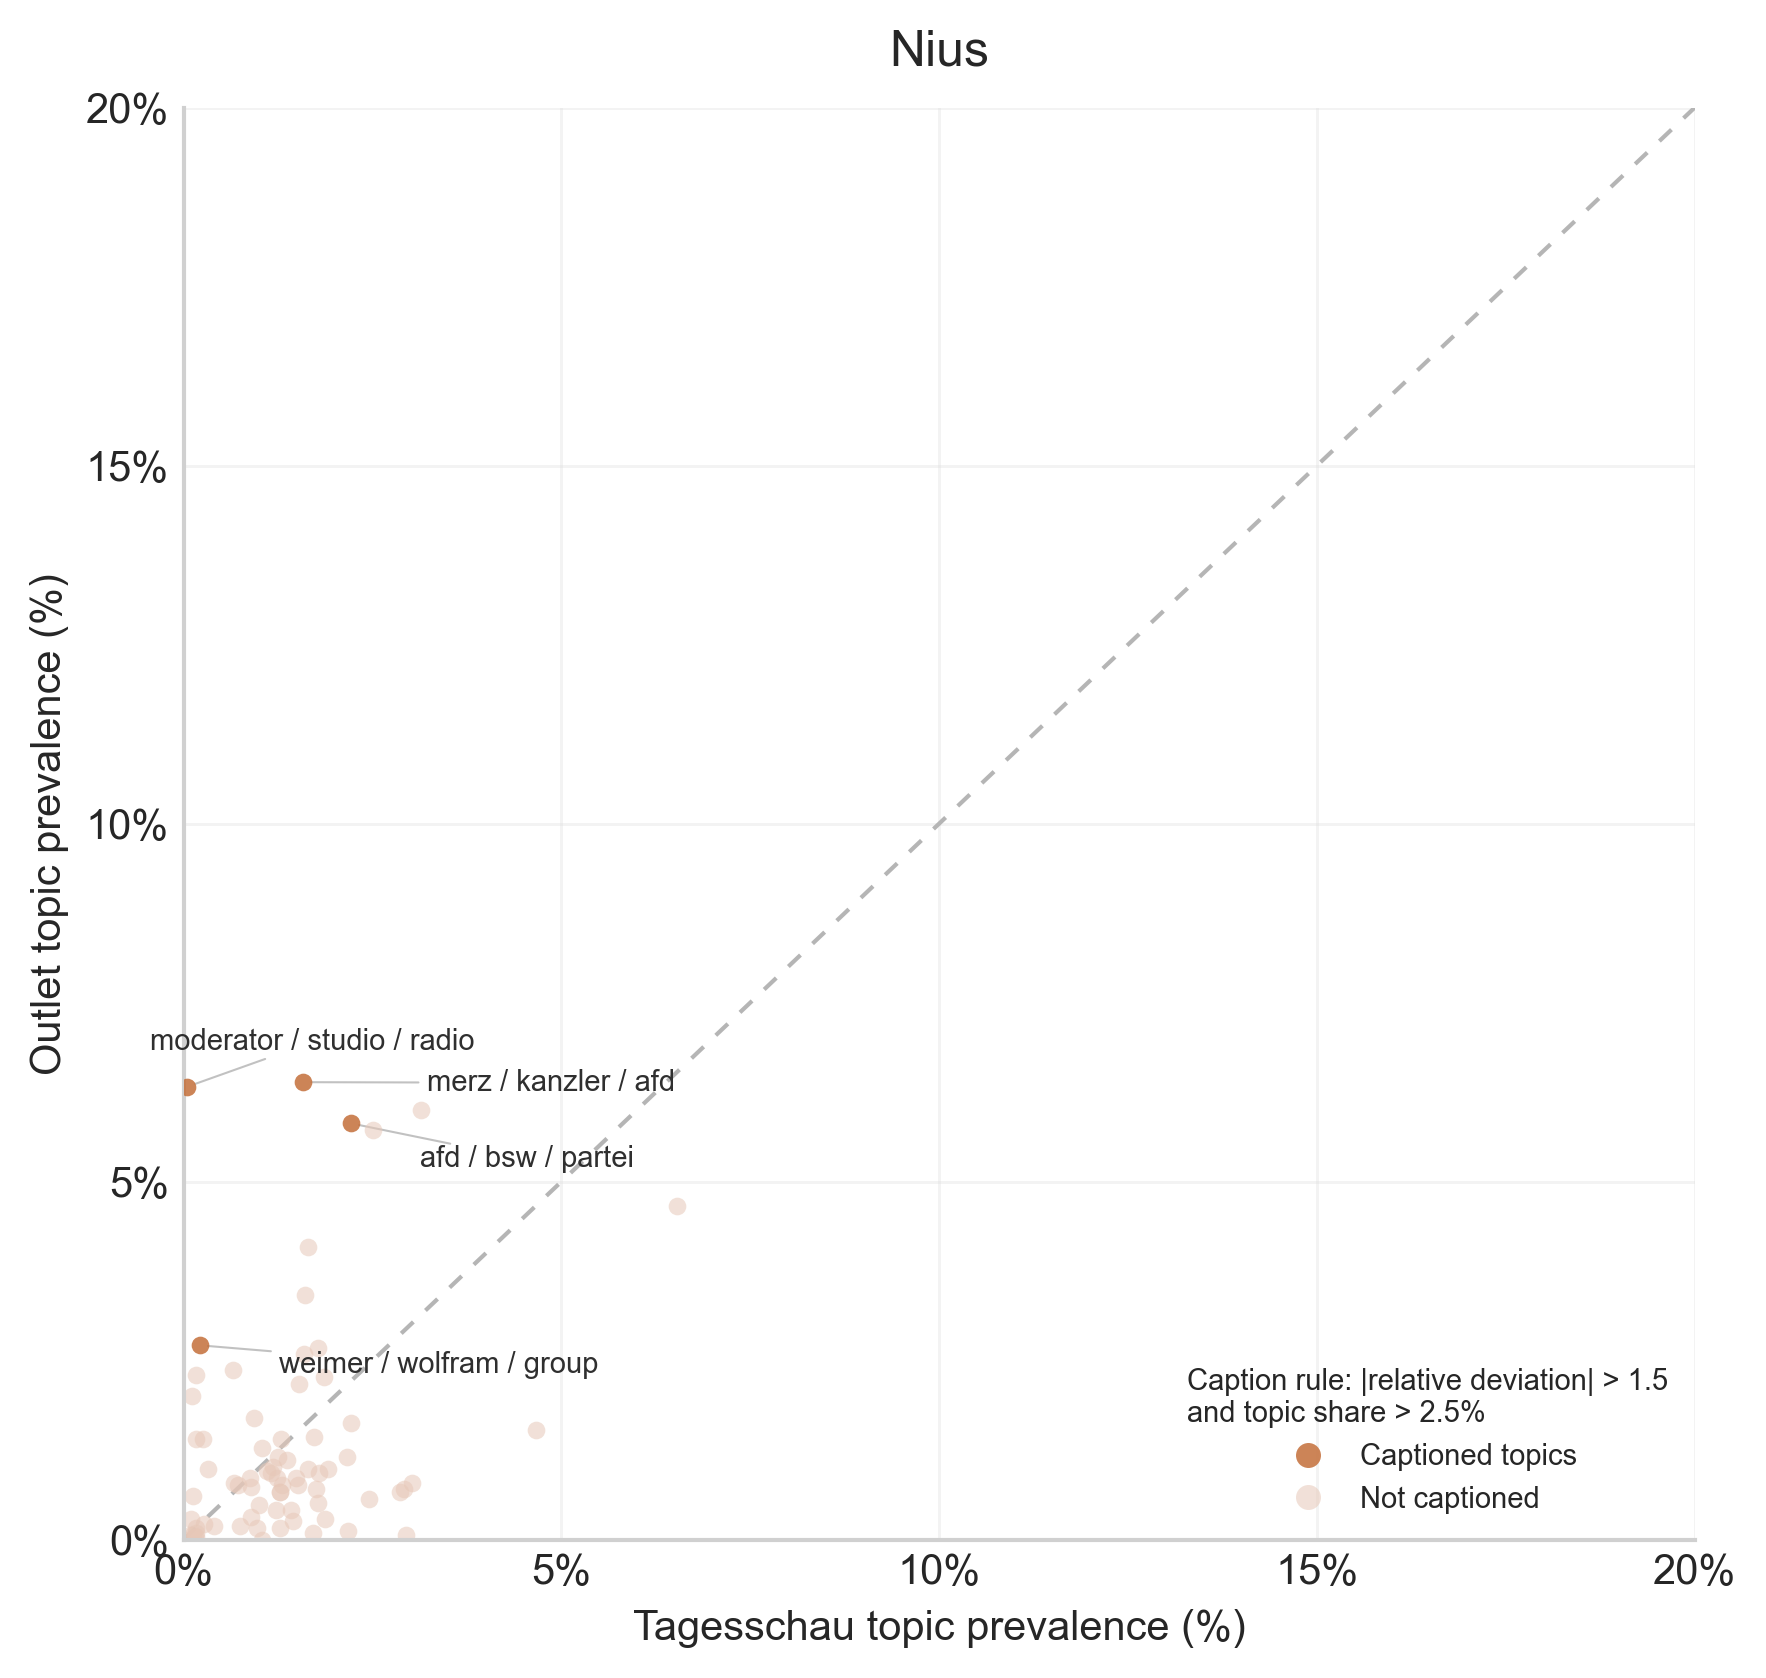

### Tichys Einblick

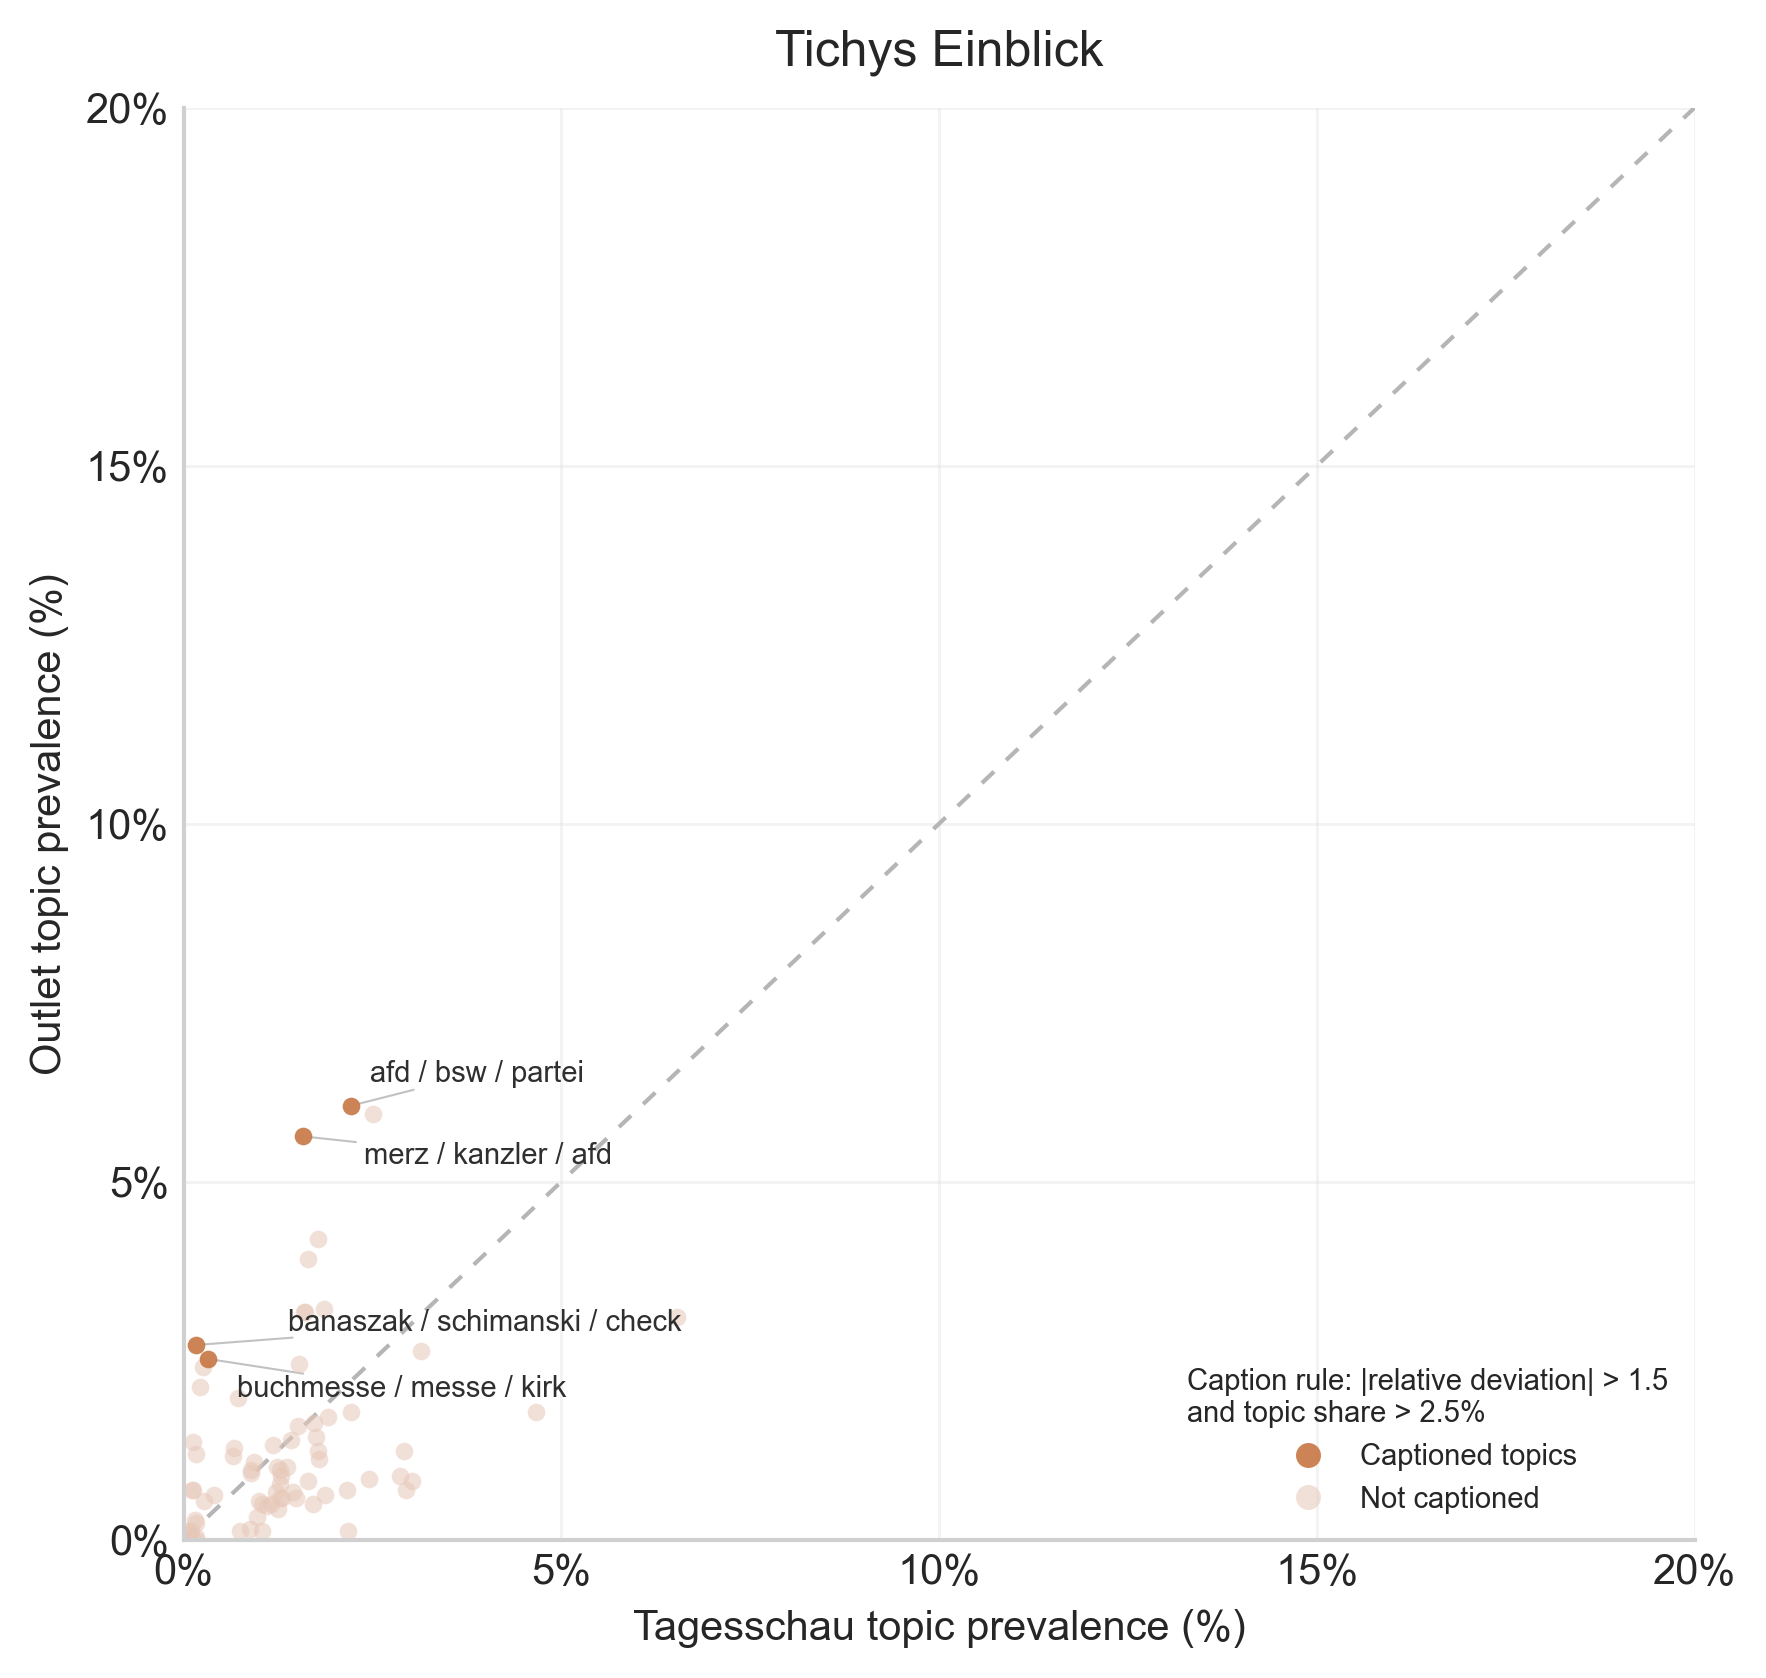

Figures rendered inline only. No files saved.


In [5]:
scatter_image_payloads = []
labeled_topic_tables = {}

for outlet_key in OUTLET_ORDER:
    fig, ax = plt.subplots(figsize=(6.5, 6.2), dpi=150)
    outlet_df = plot_single_outlet_scatter(ax, outlet_key, show_legend=True)
    ax.set_xlabel("Tagesschau topic prevalence (%)")
    ax.set_ylabel("Outlet topic prevalence (%)")

    buffer = BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight", dpi=300, facecolor="white")
    buffer.seek(0)
    plt.close(fig)

    scatter_image_payloads.append((OUTLET_LABEL_MAP[outlet_key], buffer.getvalue()))
    labeled_topic_tables[outlet_key] = outlet_df.loc[outlet_df["should_label"]].copy()

grid_fig, grid_axes = plt.subplots(
    3,
    2,
    figsize=(13, 16),
    dpi=150,
    sharex=True,
    sharey=True,
)
for ax, outlet_key in zip(grid_axes.flat, OUTLET_ORDER):
    plot_single_outlet_scatter(ax, outlet_key, show_legend=False)

legend_handles, legend_title = scatter_legend_handles()
grid_fig.legend(
    handles=legend_handles,
    title=legend_title,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=2,
    fontsize=8,
    title_fontsize=8,
    frameon=False,
)
grid_fig.supxlabel("Tagesschau topic prevalence (%)", fontsize=12, y=0.04)
grid_fig.supylabel("Outlet topic prevalence (%)", fontsize=12, x=0.04)
grid_fig.tight_layout(rect=(0.05, 0.08, 1.0, 1.0))

grid_buffer = BytesIO()
grid_fig.savefig(grid_buffer, format="png", bbox_inches="tight", dpi=300, facecolor="white")
grid_buffer.seek(0)
plt.close(grid_fig)

display(Markdown("### Combined grid"))
display(Image(data=grid_buffer.getvalue()))

for outlet_label, image_bytes in scatter_image_payloads:
    display(Markdown(f"### {outlet_label}"))
    display(Image(data=image_bytes))

print("Figures rendered inline only. No files saved.")

## 6. Diagnostic Summary

This final cell prints which topics were captioned in each outlet panel.

In [6]:
for outlet_key in OUTLET_ORDER:
    outlet_label = OUTLET_LABEL_MAP[outlet_key]
    labeled_df = labeled_topic_tables[outlet_key].sort_values(
        ["combined_share_pct", "relative_deviation"],
        ascending=[False, False],
    ).reset_index(drop=True)

    print()
    print("=" * 90)
    print(
        f"{outlet_label} — captioned topics: {len(labeled_df)} "
        f"(thresholds: |relative_deviation| > {LABEL_RELATIVE_DEVIATION_THRESHOLD:.1f}, "
        f"topic share > {LABEL_SHARE_THRESHOLD_PCT:.1f}%)"
    )
    if labeled_df.empty:
        print("No topics met the caption rule.")
        continue

    for _, row in labeled_df.iterrows():
        print(
            f"  Topic {int(row['merged_topic']):>2} | "
            f"{row['plot_label']:<35} | "
            f"Tagesschau={row['tagesschau_share_pct']:>5.2f}% | "
            f"Outlet={row['outlet_share_pct']:>5.2f}% | "
            f"relative_deviation={row['relative_deviation']:>6.2f}"
        )

    display(
        labeled_df[
            [
                "merged_topic",
                "plot_label",
                "raw_label",
                "tagesschau_share_pct",
                "outlet_share_pct",
                "relative_deviation",
            ]
        ]
    )


RT — captioned topics: 4 (thresholds: |relative_deviation| > 1.5, topic share > 2.5%)
  Topic  1 | ukraine / putin / selenskyj         | Tagesschau= 4.66% | Outlet=12.08% | relative_deviation=  1.59
  Topic 22 | russland / ukraine / russischen     | Tagesschau= 1.76% | Outlet=11.08% | relative_deviation=  5.30
  Topic  5 | ukraine / russland / russischen     | Tagesschau= 2.87% | Outlet= 9.45% | relative_deviation=  2.29
  Topic 34 | drohnen / nato / polen              | Tagesschau= 1.87% | Outlet= 4.85% | relative_deviation=  1.59


,merged_topic,plot_label,raw_label,tagesschau_share_pct,outlet_share_pct,relative_deviation
0,1,ukraine / putin / selenskyj,ukraine_putin_selenskyj_trump,4.659498,12.075215,1.591527
1,22,russland / ukraine / russischen,russland_ukraine_russischen_russische,1.759531,11.078387,5.296217
2,5,ukraine / russland / russischen,ukraine_russland_russischen_ukrainische,2.867384,9.447213,2.294716
3,34,drohnen / nato / polen,drohnen_nato_polen_luftraum,1.873574,4.848210,1.587680



Antispiegel — captioned topics: 6 (thresholds: |relative_deviation| > 1.5, topic share > 2.5%)
  Topic  1 | ukraine / putin / selenskyj         | Tagesschau= 4.66% | Outlet=17.80% | relative_deviation=  2.82
  Topic 22 | russland / ukraine / russischen     | Tagesschau= 1.76% | Outlet=18.90% | relative_deviation=  9.74
  Topic  5 | ukraine / russland / russischen     | Tagesschau= 2.87% | Outlet=12.66% | relative_deviation=  3.42
  Topic 58 | spiegel / bellingcat / journalisten | Tagesschau= 0.13% | Outlet= 7.52% | relative_deviation= 56.72
  Topic 11 | grönland / trump / nato             | Tagesschau= 1.91% | Outlet= 5.69% | relative_deviation=  1.98
  Topic 34 | drohnen / nato / polen              | Tagesschau= 1.87% | Outlet= 4.95% | relative_deviation=  1.64


,merged_topic,plot_label,raw_label,tagesschau_share_pct,outlet_share_pct,relative_deviation
0,1,ukraine / putin / selenskyj,ukraine_putin_selenskyj_trump,4.659498,17.798165,2.819760
1,22,russland / ukraine / russischen,russland_ukraine_russischen_russische,1.759531,18.899083,9.740979
2,5,ukraine / russland / russischen,ukraine_russland_russischen_ukrainische,2.867384,12.660550,3.415367
3,58,spiegel / bellingcat / journalisten,spiegel_bellingcat_journalisten_occrp,0.130336,7.522936,56.719725
4,11,grönland / trump / nato,grönland_trump_nato_dänemark,1.906158,5.688073,1.984051
5,34,drohnen / nato / polen,drohnen_nato_polen_luftraum,1.873574,4.954128,1.644212



Compact — captioned topics: 4 (thresholds: |relative_deviation| > 1.5, topic share > 2.5%)
  Topic 33 | afd / bsw / partei                  | Tagesschau= 2.22% | Outlet= 6.73% | relative_deviation=  2.04
  Topic 62 | buchmesse / messe / kirk            | Tagesschau= 0.33% | Outlet= 5.38% | relative_deviation= 15.52
  Topic 50 | merz / kanzler / afd                | Tagesschau= 1.58% | Outlet= 4.11% | relative_deviation=  1.60
  Topic 69 | silber / gold / dollar              | Tagesschau= 0.41% | Outlet= 3.47% | relative_deviation=  7.52


...

,merged_topic,plot_label,raw_label,tagesschau_share_pct,outlet_share_pct,relative_deviation
0,33,afd / bsw / partei,afd_bsw_partei_spd,2.215705,12.114537,4.467576
1,50,merz / kanzler / afd,merz_kanzler_afd_stadtbild,1.580319,8.002937,4.064126
2,23,dobrindt / asylbewerber / grenzkontrollen,dobrindt_asylbewerber_grenzkontrollen_geflüchtete,1.612903,6.167401,2.823789
3,28,spd / cdu / csu,spd_cdu_csu_koalition,1.645487,4.258443,1.587953
4,61,weimer / wolfram / group,weimer_wolfram_wolfram weimer_group,0.211795,2.936858,12.866486



Nius — captioned topics: 4 (thresholds: |relative_deviation| > 1.5, topic share > 2.5%)
  Topic 33 | afd / bsw / partei                  | Tagesschau= 2.22% | Outlet= 5.81% | relative_deviation=  1.62
  Topic 50 | merz / kanzler / afd                | Tagesschau= 1.58% | Outlet= 6.39% | relative_deviation=  3.04
  Topic 66 | moderator / studio / radio          | Tagesschau= 0.05% | Outlet= 6.33% | relative_deviation= 62.77
  Topic 61 | weimer / wolfram / group            | Tagesschau= 0.21% | Outlet= 2.72% | relative_deviation= 11.82


,merged_topic,plot_label,raw_label,tagesschau_share_pct,outlet_share_pct,relative_deviation
0,33,afd / bsw / partei,afd_bsw_partei_spd,2.215705,5.814696,1.624309
1,50,merz / kanzler / afd,merz_kanzler_afd_stadtbild,1.580319,6.389776,3.043345
2,66,moderator / studio / radio,moderator_studio_radio_abend,0.048876,6.325879,62.770027
3,61,weimer / wolfram / group,weimer_wolfram_wolfram weimer_group,0.211795,2.715655,11.822069



Tichys Einblick — captioned topics: 4 (thresholds: |relative_deviation| > 1.5, topic share > 2.5%)
  Topic 33 | afd / bsw / partei                  | Tagesschau= 2.22% | Outlet= 6.06% | relative_deviation=  1.74
  Topic 50 | merz / kanzler / afd                | Tagesschau= 1.58% | Outlet= 5.63% | relative_deviation=  2.56
  Topic 63 | banaszak / schimanski / check       | Tagesschau= 0.16% | Outlet= 2.72% | relative_deviation= 15.69
  Topic 62 | buchmesse / messe / kirk            | Tagesschau= 0.33% | Outlet= 2.53% | relative_deviation=  6.75


,merged_topic,plot_label,raw_label,tagesschau_share_pct,outlet_share_pct,relative_deviation
0,33,afd / bsw / partei,afd_bsw_partei_spd,2.215705,6.060606,1.735294
1,50,merz / kanzler / afd,merz_kanzler_afd_stadtbild,1.580319,5.633256,2.564631
2,63,banaszak / schimanski / check,banaszak_schimanski_check_brantner,0.162920,2.719503,15.692308
3,62,buchmesse / messe / kirk,buchmesse_messe_kirk_halle,0.325839,2.525253,6.750000
